# CDOM vs. Chl-a in Tara

In [12]:
from importlib import reload
import sys, os
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import cartopy
#mpl.rcParams['font.family'] = 'stixgeneral'

from ocpy.utils import plotting as oc_plotting
from ocpy.tara import io as tara_io

from bing import parameters as param20
from bing.parameters import standard 
from bing.fitting import l23
from bing.fitting import inference
from bing import plotting

In [13]:
tformM = ccrs.Mollweide()
tformP = ccrs.PlateCarree()  

# Load Tara

In [3]:
tara_db = tara_io.load_pg_db(expedition='Microbiome')

Reading: /home/xavier/Projects/Oceanography/python/ocpy/ocpy/data/Tara/TaraMicrobiome_fCDOM_interpolation_Rottgers2013_semiempirical_scattering_correction.feather
Using bit_flags removes 53284 rows of a total 332076


## What's inside?

In [7]:
tara_db.keys()

Index(['dt', 'lat', 'lon', 'sst', 'sss', 'ap400.0', 'ap402.6', 'ap405.5',
       'ap408.7', 'ap413.5',
       ...
       'Halh', 'chl_Halh', 'HH_G50', 'HH_mphi', 'flag_bit', 'geometry',
       'datetime', 'uid', 'mission_id', 'passes_flags'],
      dtype='object', length=355)

# FDOM vs. Chl-a

In [14]:
good = (tara_db.chl_Halh > 0.) & (tara_db.fdom > 0.)
cut_tara = tara_db[good].copy()

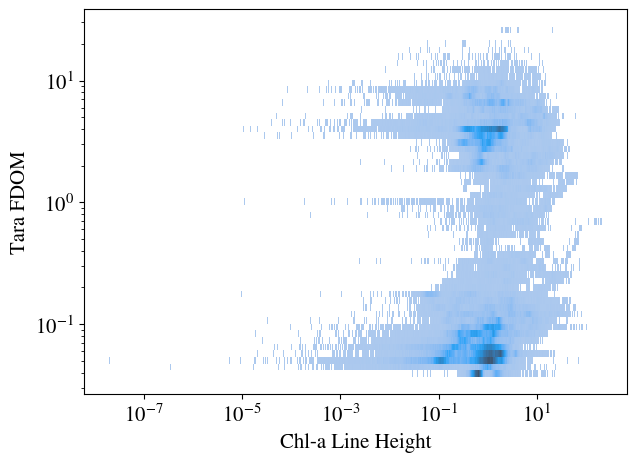

In [15]:
fig = plt.figure(figsize=(7,5))

plt.clf()
ax = plt.gca()
#
ax = sns.histplot(x=cut_tara.chl_Halh, y=cut_tara.fdom, log_scale=True)
#
ax.set_xlabel('Chl-a Line Height')
ax.set_ylabel('Tara FDOM')
#ax.set_ylabel(r'CDOM from $a_g$')
#ax.legend()
oc_plotting.set_fontsize(ax,15)
#
plt.show()

In [18]:
cut_tara.lon

utc_dt
2020-12-26 19:39:00   -11.259457
2020-12-26 19:40:00   -11.260808
2020-12-26 19:41:00   -11.262016
2020-12-26 19:42:00   -11.263350
2020-12-26 19:43:00   -11.264705
                         ...    
2022-09-17 13:28:00   -17.384236
2022-09-17 13:29:00   -17.385693
2022-09-17 13:30:00   -17.387150
2022-09-17 13:31:00   -17.388613
2022-09-17 13:32:00   -17.390075
Name: lon, Length: 254419, dtype: float64

# Geographic

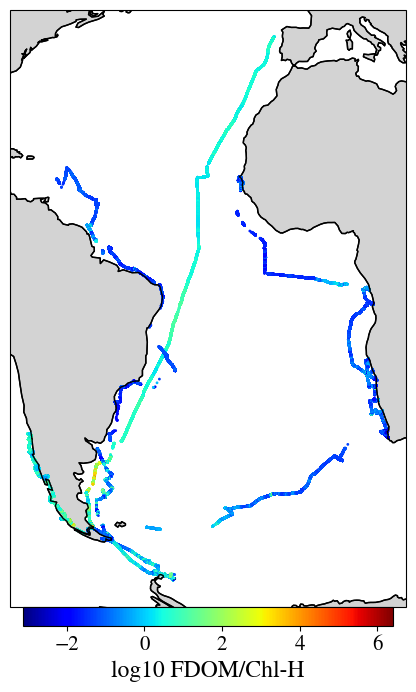

In [23]:
fig = plt.figure(figsize=(7,8))
plt.clf()

ax = plt.subplot(projection=tformM)

lons = cut_tara.lon.values
lats = cut_tara.lat.values

metric = np.log10(cut_tara.fdom / cut_tara.chl_Halh)

img = plt.scatter(x=lons,
    y=lats, c=metric, cmap='jet',
        #vmin=0.,
        #vmax=vmax, 
    s=1,
    transform=tformP)#, label=param)

# Color bar
cbaxes = plt.colorbar(img, pad=0., fraction=0.030, orientation='horizontal') #location='left')
cbaxes.set_label('log10 FDOM/Chl-H', fontsize=17.)
cbaxes.ax.tick_params(labelsize=15)

# Coast lines
ax.coastlines(zorder=10)
ax.add_feature(cartopy.feature.LAND, 
    facecolor='lightgray', edgecolor='black')
#ax.set_global()

#lon_min, lon_max, lat_min, lat_max = -100, 30, -70, 50
#ax.set_extent([lon_min, lon_max, lat_min, lat_max])

plt.show()
